# User Behavior Segmentation using K-Means
This notebook follows a step-by-step machine learning workflow for clustering app users based on engagement behavior.

In [ ]:

# Step 1: Import Libraries


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA


In [ ]:

# Step 2: Data Collection


df = pd.read_csv("app_user_behavior_dataset.csv")

print("Dataset Shape:", df.shape)
df.head()


Dataset Shape: (50000, 25)


,user_id,age,gender,country,device_type,app_version,sessions_per_week,avg_session_duration_min,daily_active_minutes,feature_clicks_per_session,...,days_since_last_login,subscription_type,ads_clicked_last_30_days,content_downloads,social_shares,rating_given,churn_risk_score,engagement_score,account_age_days,marketing_source
0,100000,56,Female,India,iOS,2.1,5,3.41,52.71,13,...,20,Basic,9,5,2,NaN,0.31,55.79,1152,Referral
1,100001,46,Male,UK,iOS,1.0,8,24.44,42.03,7,...,7,Free,8,3,3,3.0,0.87,82.39,1059,Email Campaign
2,100002,32,Female,UK,iOS,1.2,12,5.34,76.69,7,...,33,Free,11,6,1,2.0,0.63,42.49,678,Google Ads
3,100003,25,Male,India,Android,2.0,5,3.98,65.38,16,...,17,Basic,6,3,1,3.0,0.43,62.81,92,Organic
4,100004,38,Male,Australia,Android,1.0,10,12.85,57.06,13,...,21,Basic,4,4,2,5.0,0.43,38.21,772,Email Campaign


In [ ]:

# Step 3: Data Understanding


print("\nDataset Info\n")
print(df.info())

print("\nStatistical Summary\n")
print(df.describe())



Dataset Info

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 25 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   user_id                        50000 non-null  int64  
 1   age                            50000 non-null  int64  
 2   gender                         50000 non-null  object 
 3   country                        50000 non-null  object 
 4   device_type                    50000 non-null  object 
 5   app_version                    50000 non-null  float64
 6   sessions_per_week              50000 non-null  int64  
 7   avg_session_duration_min       50000 non-null  float64
 8   daily_active_minutes           50000 non-null  float64
 9   feature_clicks_per_session     50000 non-null  int64  
 10  notifications_opened_per_week  50000 non-null  int64  
 11  in_app_search_count            50000 non-null  int64  
 12  pages_viewed_per_session       

In [ ]:

# Step 4: Data Cleaning


# Check missing values
print("\nMissing Values Before Cleaning\n")
print(df.isnull().sum())

# Fill missing values for numerical columns
numeric_cols = df.select_dtypes(include=["int64","float64"]).columns

df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

print("\nMissing Values After Cleaning\n")
print(df.isnull().sum())



Missing Values Before Cleaning

user_id                          0
age                              0
gender                           0
country                          0
device_type                      0
app_version                      0
sessions_per_week                0
avg_session_duration_min         0
daily_active_minutes             0
feature_clicks_per_session       0
notifications_opened_per_week    0
in_app_search_count              0
pages_viewed_per_session         0
crash_events_last_30_days        0
support_tickets_raised           0
days_since_last_login            0
subscription_type                0
ads_clicked_last_30_days         0
content_downloads                0
social_shares                    0
rating_given                     0
churn_risk_score                 0
engagement_score                 0
account_age_days                 0
marketing_source                 0
dtype: int64

Missing Values After Cleaning

user_id                          0
age         

In [ ]:

# Step 5: Feature Selection


features = [
    "sessions_per_week",
    "avg_session_duration_min",
    "daily_active_minutes",
    "engagement_score"
]

X = df[features]

print("\nSelected Features\n")
print(X.head())



Selected Features

   sessions_per_week  avg_session_duration_min  daily_active_minutes  \
0                  5                      3.41                 52.71   
1                  8                     24.44                 42.03   
2                 12                      5.34                 76.69   
3                  5                      3.98                 65.38   
4                 10                     12.85                 57.06   

   engagement_score  
0             55.79  
1             82.39  
2             42.49  
3             62.81  
4             38.21  


In [ ]:

# Step 6: Data Scaling


scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)


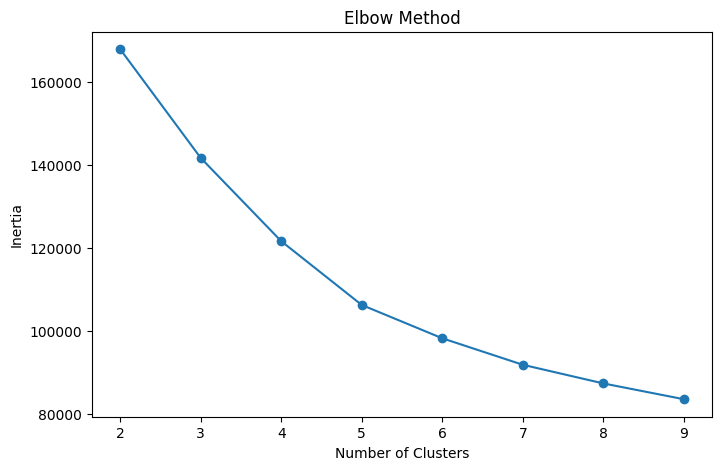

In [ ]:

# Step 7: Optimal Cluster Identification (Elbow Method)


inertia = []
K = range(2,10)

for k in K:
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(X_scaled)
    inertia.append(model.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K, inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()


In [ ]:

# Step 8: Train K-Means Model


kmeans = KMeans(n_clusters=4, random_state=42)

df["cluster"] = kmeans.fit_predict(X_scaled)

print(df.head())


   user_id  age  gender    country device_type  app_version  \
0   100000   56  Female      India         iOS          2.1   
1   100001   46    Male         UK         iOS          1.0   
2   100002   32  Female         UK         iOS          1.2   
3   100003   25    Male      India     Android          2.0   
4   100004   38    Male  Australia     Android          1.0   

   sessions_per_week  avg_session_duration_min  daily_active_minutes  \
0                  5                      3.41                 52.71   
1                  8                     24.44                 42.03   
2                 12                      5.34                 76.69   
3                  5                      3.98                 65.38   
4                 10                     12.85                 57.06   

   feature_clicks_per_session  ...  subscription_type  \
0                          13  ...              Basic   
1                           7  ...               Free   
2                

In [ ]:

# Step 9: Cluster Profiling


cluster_summary = df.groupby("cluster")[features].mean()
cluster_counts = df["cluster"].value_counts()

print("\nCluster Summary\n")
print(cluster_summary)

print("\nCluster Counts\n")
print(cluster_counts)



Cluster Summary

         sessions_per_week  avg_session_duration_min  daily_active_minutes  \
cluster                                                                      
0                 6.683482                 10.061304             62.188687   
1                11.417732                 10.631560             44.593263   
2                 7.808833                 28.974423             44.953058   
3                 6.544019                 10.232352             28.653168   

         engagement_score  
cluster                    
0               69.279742  
1               64.908707  
2               64.954454  
3               60.600987  

Cluster Counts

cluster
0    14947
3    14880
1    12520
2     7653
Name: count, dtype: int64


In [ ]:

# Step 10: Identify Users in Each Cluster


for i in range(4):
    print(f"\nUsers in Cluster {i}")
    print(df[df["cluster"]==i]["user_id"].head())



Users in Cluster 0
0     100000
3     100003
11    100011
16    100016
17    100017
Name: user_id, dtype: int64

Users in Cluster 1
2     100002
4     100004
5     100005
10    100010
18    100018
Name: user_id, dtype: int64

Users in Cluster 2
1     100001
8     100008
9     100009
15    100015
36    100036
Name: user_id, dtype: int64

Users in Cluster 3
6     100006
7     100007
12    100012
13    100013
14    100014
Name: user_id, dtype: int64


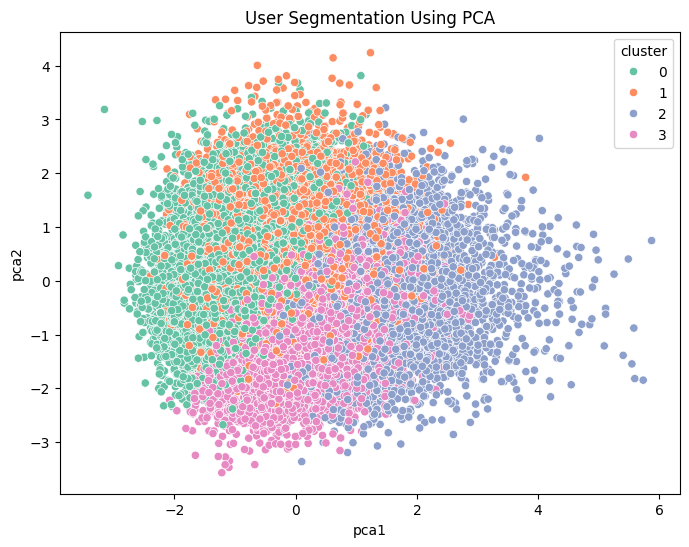

In [ ]:

# Step 11: PCA Visualization


pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

df["pca1"] = X_pca[:,0]
df["pca2"] = X_pca[:,1]

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="pca1",
    y="pca2",
    hue="cluster",
    palette="Set2"
)

plt.title("User Segmentation Using PCA")

plt.show()


In [ ]:

# Step 12: Export Results

df.to_csv("user_segmentation_results.csv", index=False)
